HOUSE PRICE PREDICTION
This project predicts house pricesusing machine learning models

In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

In [3]:
df = pd.read_csv("Housing.csv")
print("Dataset Loaded Successfully")
df.head(10)

Dataset Loaded Successfully


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


In [4]:
print("shape of dataset:",df.shape)
print("\nColumn Names:")
print(df.columns)
print("\nMissingValues:")
print(df.isnull().sum())

shape of dataset: (545, 13)

Column Names:
Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='str')

MissingValues:
price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64


In [5]:
df = df.drop_duplicates()
print("shape after removing duplicates:",df.shape)

shape after removing duplicates: (545, 13)


In [9]:
df = pd.get_dummies(df,drop_first=True)
df.head()
print(df.columns)
df.head()
print(df.columns.tolist())

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'parking',
       'mainroad_yes', 'guestroom_yes', 'basement_yes', 'hotwaterheating_yes',
       'airconditioning_yes', 'prefarea_yes',
       'furnishingstatus_semi-furnished', 'furnishingstatus_unfurnished'],
      dtype='str')
['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'parking', 'mainroad_yes', 'guestroom_yes', 'basement_yes', 'hotwaterheating_yes', 'airconditioning_yes', 'prefarea_yes', 'furnishingstatus_semi-furnished', 'furnishingstatus_unfurnished']


In [10]:
x = df.drop("price",axis =1)
y = df["price"]
print("X shape:",x.shape)
print("Y shape:",y.shape)

X shape: (545, 13)
Y shape: (545,)


In [11]:
from sklearn.model_selection import train_test_split 
x_train,x_test,y_train,y_test=train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42
)
print("training data:",x_train.shape)
print("testing data:",x_test.shape)

training data: (436, 13)
testing data: (109, 13)


In [12]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(x_train,y_train)
y_pred_lr =lr.predict(x_test)
print("linear regression model trained successfully")

linear regression model trained successfully


In [13]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
import numpy as np
mae_lr = mean_absolute_error(y_test,y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test,y_pred_lr))
r2_lr = r2_score(y_test,y_pred_lr)
print("Linear Regression Results")
print("Mae:",mae_lr)
print("RMSE:",rmse_lr)
print("R2 score:",r2_lr)


Linear Regression Results
Mae: 970043.4039201637
RMSE: 1324506.9600914388
R2 score: 0.6529242642153184


In [16]:
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(
    n_estimators = 100,
    random_state=42
)
rf.fit(x_train,y_train)
y_pred_rf = rf.predict(x_test)
print("Random Forest Model Trained Successfully ")

Random Forest Model Trained Successfully 


In [17]:
mae_rf =mean_absolute_error(y_test,y_pred_rf)
rmse_rf =np.sqrt(mean_squared_error(y_test,y_pred_rf))
r2_rf=r2_score(y_test,y_pred_rf)
print("Random Forest Results")
print("Mae:",mae_rf)
print("Rmse:",rmse_rf)
print("R2 Score:",r2_rf)

Random Forest Results
Mae: 1021546.0353211008
Rmse: 1400565.9728553821
R2 Score: 0.611918531405699


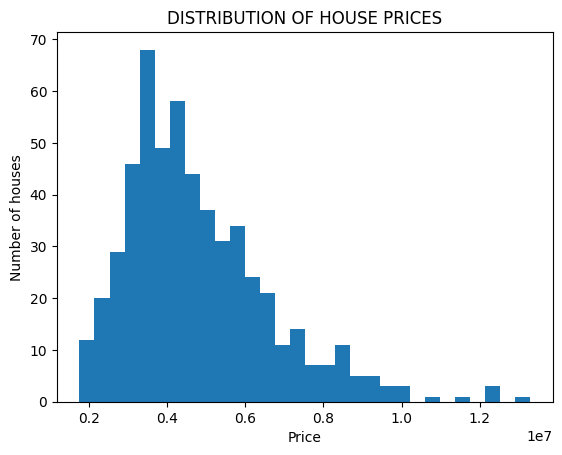

In [24]:
plt.Figure(figsize=(8,5))
plt.hist(df["price"],bins =30)
plt.title("DISTRIBUTION OF HOUSE PRICES")
plt.xlabel("Price")
plt.ylabel("Number of houses")
plt.savefig("price_distribution.png")
plt.show()

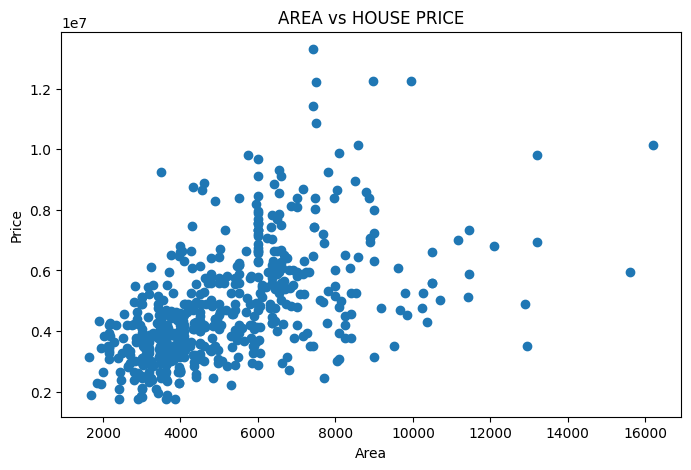

In [28]:
plt.figure(figsize=(8,5))
plt.scatter(df["area"],df["price"])
plt.title("AREA vs HOUSE PRICE")
plt.xlabel("Area")
plt.ylabel("Price")
plt.savefig("area_vs_price.png")
plt.show()

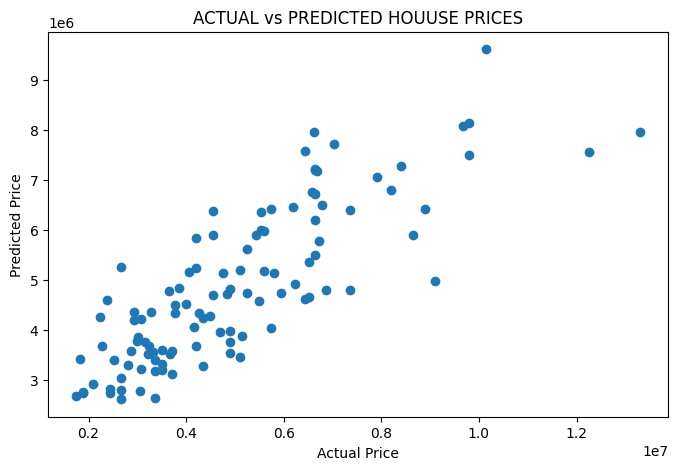

In [31]:
plt.figure(figsize=(8,5))
plt.scatter(y_test,y_pred_lr)
plt.title("ACTUAL vs PREDICTED HOUUSE PRICES")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.savefig("actual_vs_predicted.png")
plt.show()

In [32]:
comparison = pd.DataFrame({"Model":["Linear Regression","Random Forest"],
                           "MAE":[mae_lr,mae_rf],
                           "RMSE":[rmse_lr,rmse_rf],
                           "R2 Score":[ r2_lr,r2_rf]
                           })
comparison

,Model,MAE,RMSE,R2 Score
0,Linear Regression,9.700434e+05,1.324507e+06,0.652924
1,Random Forest,1.021546e+06,1.400566e+06,0.611919


## CONCLUSION

Two machine learning models were developed to predict house orices,Linear REgression performed better with an R2 score of approximately 0.65.Area,bedrooms,and bathrooms were important factors affecting house prices